# 1 · Prices and Returns

*Common Core — everyone starts here*

Prices are what you see on a screen. Returns are what you actually analyse. This notebook explains why, and shows the two ways of measuring a return that every other notebook uses.

## 1. Motivation

Apple traded at about &#36;6.40 in January 2010 (adjusted for later splits and dividends) and at about &#36;333 in September 2026. Did it go up "5,000%"? By "27% a year"? By "about 0.1% a day"? All three describe the same price path, and each is right for some purposes and misleading for others. If you pick the wrong one for the job, risk numbers, backtests and portfolio weights all come out wrong. Choosing the right return measure is the first decision in every quant project.

## 2. Intuition

A price on its own tells you little. A &#36;500 stock is not "more expensive" than a &#36;50 stock in any useful sense. What matters is **how fast your money grows**. That growth rate is the **return**.

There are two common ways to measure it, and each is convenient for a different job:

- **Simple returns** answer "what percentage did I make?" They are easy to combine *across assets*: a portfolio's return is just the weighted average of its assets' returns.
- **Log returns** are easy to combine *across time*: the return over a year is just the sum of the daily log returns.

Think of simple returns as what your bank statement shows, and log returns as what is convenient for the maths. For small daily moves the two are almost identical. Over long periods, or during big moves, they drift apart.

## 3. The math

Let $P_t$ be the price on day $t$. We always use the **adjusted** price, which corrects for stock splits and adds back dividends. Without the adjustment, a 4-for-1 split would look like a 75% crash.

**Simple return** over one day:
$$
R_t = \frac{P_t}{P_{t-1}} - 1
$$

**Log return** over one day:
$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln(1 + R_t)
$$

**Across time.** Over $T$ days, simple returns *compound* (multiply), while log returns *add*:
$$
1 + R_{0\to T} = \prod_{t=1}^{T} (1 + R_t), \qquad r_{0\to T} = \sum_{t=1}^{T} r_t .
$$

**Across assets.** A portfolio with weights $w_i$ (summing to 1) has simple return $R_p = \sum_i w_i R_i$. There is no equally clean formula for log returns, which is why portfolio notebooks use simple returns.

**Annualising.** The honest "per year" number is the **compound annual growth rate**:
$$
\text{CAGR} = \left(\frac{P_T}{P_0}\right)^{1/\text{years}} - 1 .
$$
Multiplying the average daily simple return by 252 trading days gives a *larger* number, $\mu_{\text{annual}}$. To see by how much, look at the **log growth rate** $g = \ln(1+\text{CAGR})$, the average log return per year. It sits below the average simple return by roughly half the variance:
$$
g = \ln(1 + \text{CAGR}) \approx \mu_{\text{annual}} - \tfrac{1}{2}\sigma^2_{\text{annual}} .
$$

<details><summary><b>Why volatility drags down growth (click to expand)</b></summary>

Take logs of the compounding formula: $\ln(1+R_{0\to T}) = \sum_t \ln(1+R_t)$. A second-order Taylor expansion gives $\ln(1+R) \approx R - \tfrac{1}{2}R^2$. Averaging over many days, $\mathbb{E}[R^2] = \mu^2 + \sigma^2 \approx \sigma^2$ because the daily mean $\mu$ is tiny. So the average log return is about $\mu - \tfrac12\sigma^2$. A volatile asset needs a higher average return just to grow at the same rate as a calm one. A simple example: +50% followed by −50% averages 0%, but leaves you with 75% of your money.
</details>

## 4. Code it

### 4.1 Load the shared dataset

Every notebook in the course reads the same files from `data/`. They were built once by `data/build_dataset.py`, so everyone sees the same numbers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Shared course dataset: one column per ticker, adjusted closing prices
prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

# Course plot style: fixed colour order, thin lines, light grid
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

print(prices.shape, "->", prices.index[0].date(), "to", prices.index[-1].date())
prices[["SPY", "AAPL", "TLT"]].head()

(4211, 63) -> 2010-01-04 to 2026-09-30


,SPY,AAPL,TLT
date,,,
2010-01-04,84.369003,6.400959,54.849888
2010-01-05,84.592316,6.412027,55.204140
2010-01-06,84.651894,6.310036,54.465130
2010-01-07,85.009232,6.298368,54.556751
2010-01-08,85.292084,6.340243,54.532310


### 4.2 Simple and log returns

The two formulas from Section 3 each take one line in pandas. `pct_change()` computes $P_t/P_{t-1} - 1$, and `np.log(...).diff()` computes $\ln P_t - \ln P_{t-1}$.

In [2]:
assets = ["SPY", "AAPL", "TLT"]  # the US stock market, one big stock, long-term bonds
px = prices[assets]

simple = px.pct_change().dropna()        # R_t = P_t / P_{t-1} - 1
logret = np.log(px).diff().dropna()      # r_t = ln(P_t) - ln(P_{t-1})

# For typical daily moves the two are nearly identical...
print("Largest daily gap between R_t and r_t (SPY):",
      f"{(simple['SPY'] - logret['SPY']).abs().max():.4%}")
# ...and r_t = ln(1 + R_t) holds exactly
print("Max |r_t - ln(1+R_t)|:", float((logret - np.log1p(simple)).abs().max().max()))

Largest daily gap between R_t and r_t (SPY): 0.6463%
Max |r_t - ln(1+R_t)|: 9.575673587391975e-16


### 4.3 Checking the compounding rules

Now we confirm the "across time" formulas: multiply $(1+R_t)$ day by day, or add up the $r_t$, and both should give back the total move in price.

In [3]:
total_from_prices = px.iloc[-1] / px.iloc[0] - 1             # directly from P_T / P_0
total_from_simple = (1 + simple).prod() - 1                  # product of (1 + R_t)
total_from_log = np.exp(logret.sum()) - 1                    # exp of the sum of r_t

pd.DataFrame({"from prices": total_from_prices,
              "compound simple": total_from_simple,
              "sum of logs": total_from_log}).map(lambda x: f"{x:,.1%}")

,from prices,compound simple,sum of logs
SPY,803.9%,803.9%,803.9%
AAPL,"5,102.7%","5,102.7%","5,102.7%"
TLT,41.2%,41.2%,41.2%


All three columns match. Adding up *simple* returns would **not** give the right total, and that mistake shows up a lot in student backtests.

### 4.4 Growth of &#36;1

The cumulative product $\prod(1+R_t)$ is the value of &#36;1 invested on day one. Plotting it on a log scale makes equal percentage moves look equal in size.

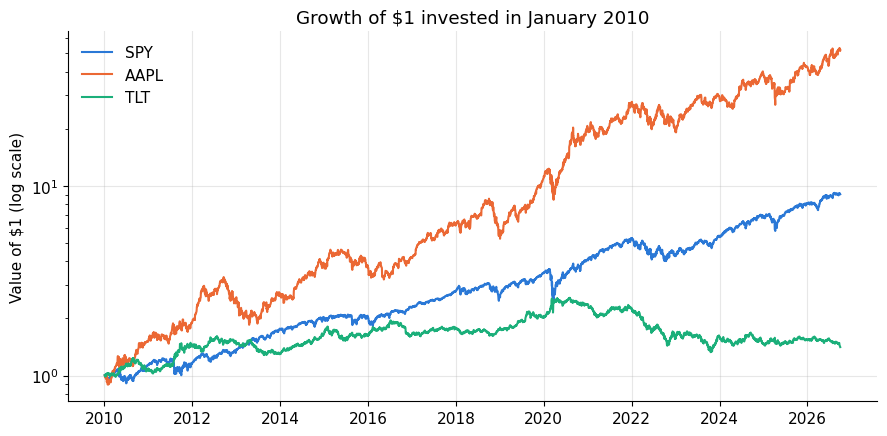

In [4]:
growth = (1 + simple).cumprod()   # value of $1 invested at the start

fig, ax = plt.subplots()
for t in assets:
    ax.plot(growth.index, growth[t], label=t)
ax.set_yscale("log")
ax.set_ylabel("Value of $1 (log scale)")
ax.set_title("Growth of $1 invested in January 2010")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 4.5 Annualising: average return vs. CAGR

Here we compute the annual numbers from Section 3 and check the "half the variance" approximation.

In [5]:
years = (px.index[-1] - px.index[0]).days / 365.25

cagr = (px.iloc[-1] / px.iloc[0]) ** (1 / years) - 1   # the growth rate you actually earned
g = np.log(1 + cagr)                                    # log growth rate per year
mu_annual = simple.mean() * 252                         # average daily return x 252
var_annual = simple.var() * 252                         # daily variance x 252

pd.DataFrame({"mean x 252": mu_annual,
              "CAGR": cagr,
              "g = ln(1+CAGR)": g,
              "mean - var/2": mu_annual - var_annual / 2,
              "volatility": np.sqrt(var_annual)}).map(lambda x: f"{x:.2%}")

,mean x 252,CAGR,g = ln(1+CAGR),mean - var/2,volatility
SPY,14.64%,14.06%,13.15%,13.18%,17.05%
AAPL,27.61%,26.63%,23.61%,23.66%,28.11%
TLT,3.18%,2.08%,2.06%,2.07%,14.90%


Two things to read off the table:

1. **The last two return columns match almost exactly.** The log growth rate is the average return minus half the variance, as the formula says.
2. **The gap between "mean × 252" and $g$ grows with volatility.** It is about 1 percentage point for TLT, about 1.5 for SPY and about 4 for AAPL, the most volatile of the three. If you quote the average return of a volatile asset as its "growth rate", you overstate it.

## 5. Takeaways and where it breaks

- **Always use adjusted prices.** Unadjusted prices turn every split into a fake crash and leave out dividends.
- **Use simple returns across assets** (portfolios) and **log returns across time** (adding up periods).
- **Volatility reduces compounded growth.** When someone quotes "average annual return", check whether they mean the mean or the CAGR.
- **Where it breaks:** returns are computed close-to-close. They ignore what you could actually trade at (the bid–ask spread, covered in notebook 5) and assume you can buy at exactly the closing price.
- **Survivorship:** AAPL is in this dataset *because* it did well. Picking stocks for analysis by looking at today's winners inflates results. Notebook 6 covers this.

**What you could build:** a small "returns toolkit" module for your team (load prices, compute both return types, annualise correctly) that every later project imports instead of re-writing.